## Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# pip install google-genai
from google import genai
from google.genai import types
import json
import getpass
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Load/Clean Data

In [ ]:
# 1. Load the data
df = pd.read_csv('Access_to_Care_Dataset.csv')

# Remove rows where ESTIMATE is missing
before_count = len(df)
df = df.dropna(subset=['ESTIMATE'])
removed = before_count - len(df)
print(f"Removed {removed:,} rows with missing ESTIMATE values ({removed/before_count*100:.1f}%)")

# Data type optimization
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
df['ESTIMATE'] = df['ESTIMATE'].astype('float32')
df['ESTIMATE_LCI'] = df['ESTIMATE_LCI'].astype('float32')
df['ESTIMATE_UCI'] = df['ESTIMATE_UCI'].astype('float32')

# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows")
    df = df.drop_duplicates()
    print(f"Removed duplicates")
else:
    print("No duplicate rows found")

Removed 2,369 rows with missing ESTIMATE values (9.0%)
No duplicate rows found


## Topic Correlation 2023

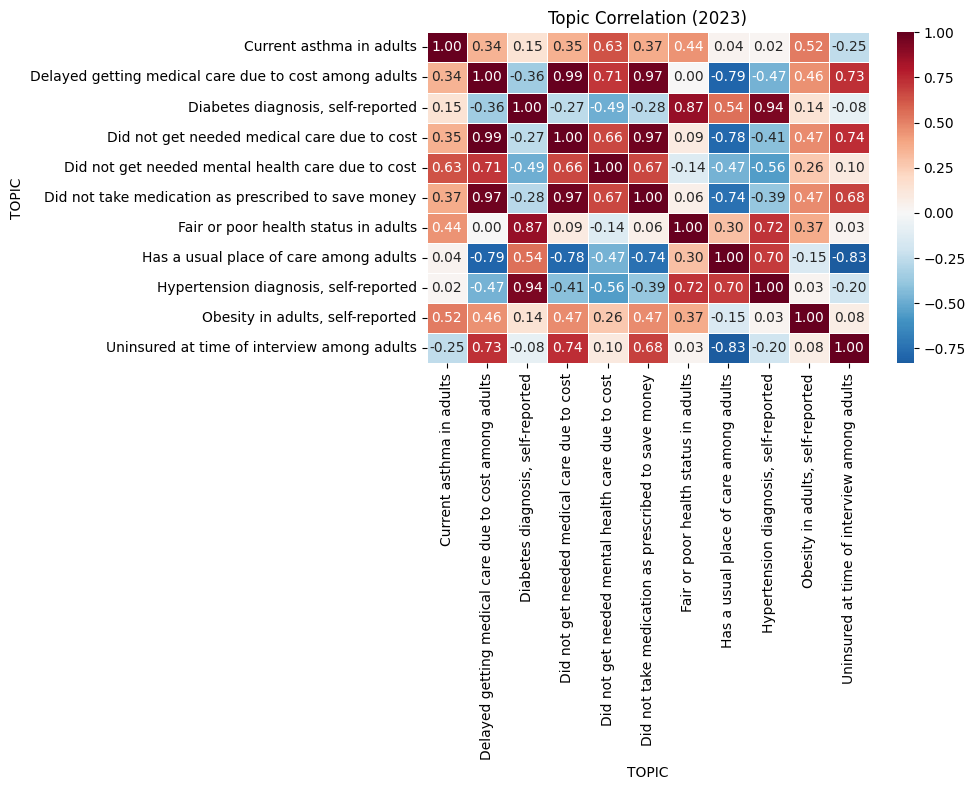

In [ ]:
target_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
    'Has a usual place of care among adults',
    'Diabetes diagnosis, self-reported',
    'Hypertension diagnosis, self-reported',
    'Obesity in adults, self-reported',
    'Current asthma in adults',
    'Fair or poor health status in adults',
    'Uninsured at time of interview among adults'
]
df_2023 = df[(df['TIME_PERIOD'] == 2023) & (df['TOPIC'].isin(target_topics))].copy()
df_2023['Profile'] = df_2023['CLASSIFICATION'] + " | " + df_2023['GROUP'] + " | " + df_2023['SUBGROUP']

# Handle nesting (e.g., distinguishing "Employed" from "Employed - Full-time")
df_2023['Profile'] = df_2023.apply(
    lambda x: x['Profile'] + " (" + str(x['NESTING_LABEL']) + ")" if pd.notnull(x['NESTING_LABEL']) else x['Profile'], axis=1
)

topic_df = df_2023.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE')
corr = topic_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,          # Show the numbers on the plot
            fmt=".2f",           # Round to 2 decimal places
            cmap='RdBu_r',       # Red-Blue color map (good for correlation)
            center=0,            # Center the color bar at 0
            linewidths=0.5)

plt.title('Topic Correlation (2023)')
plt.tight_layout()

## Topic Clustering

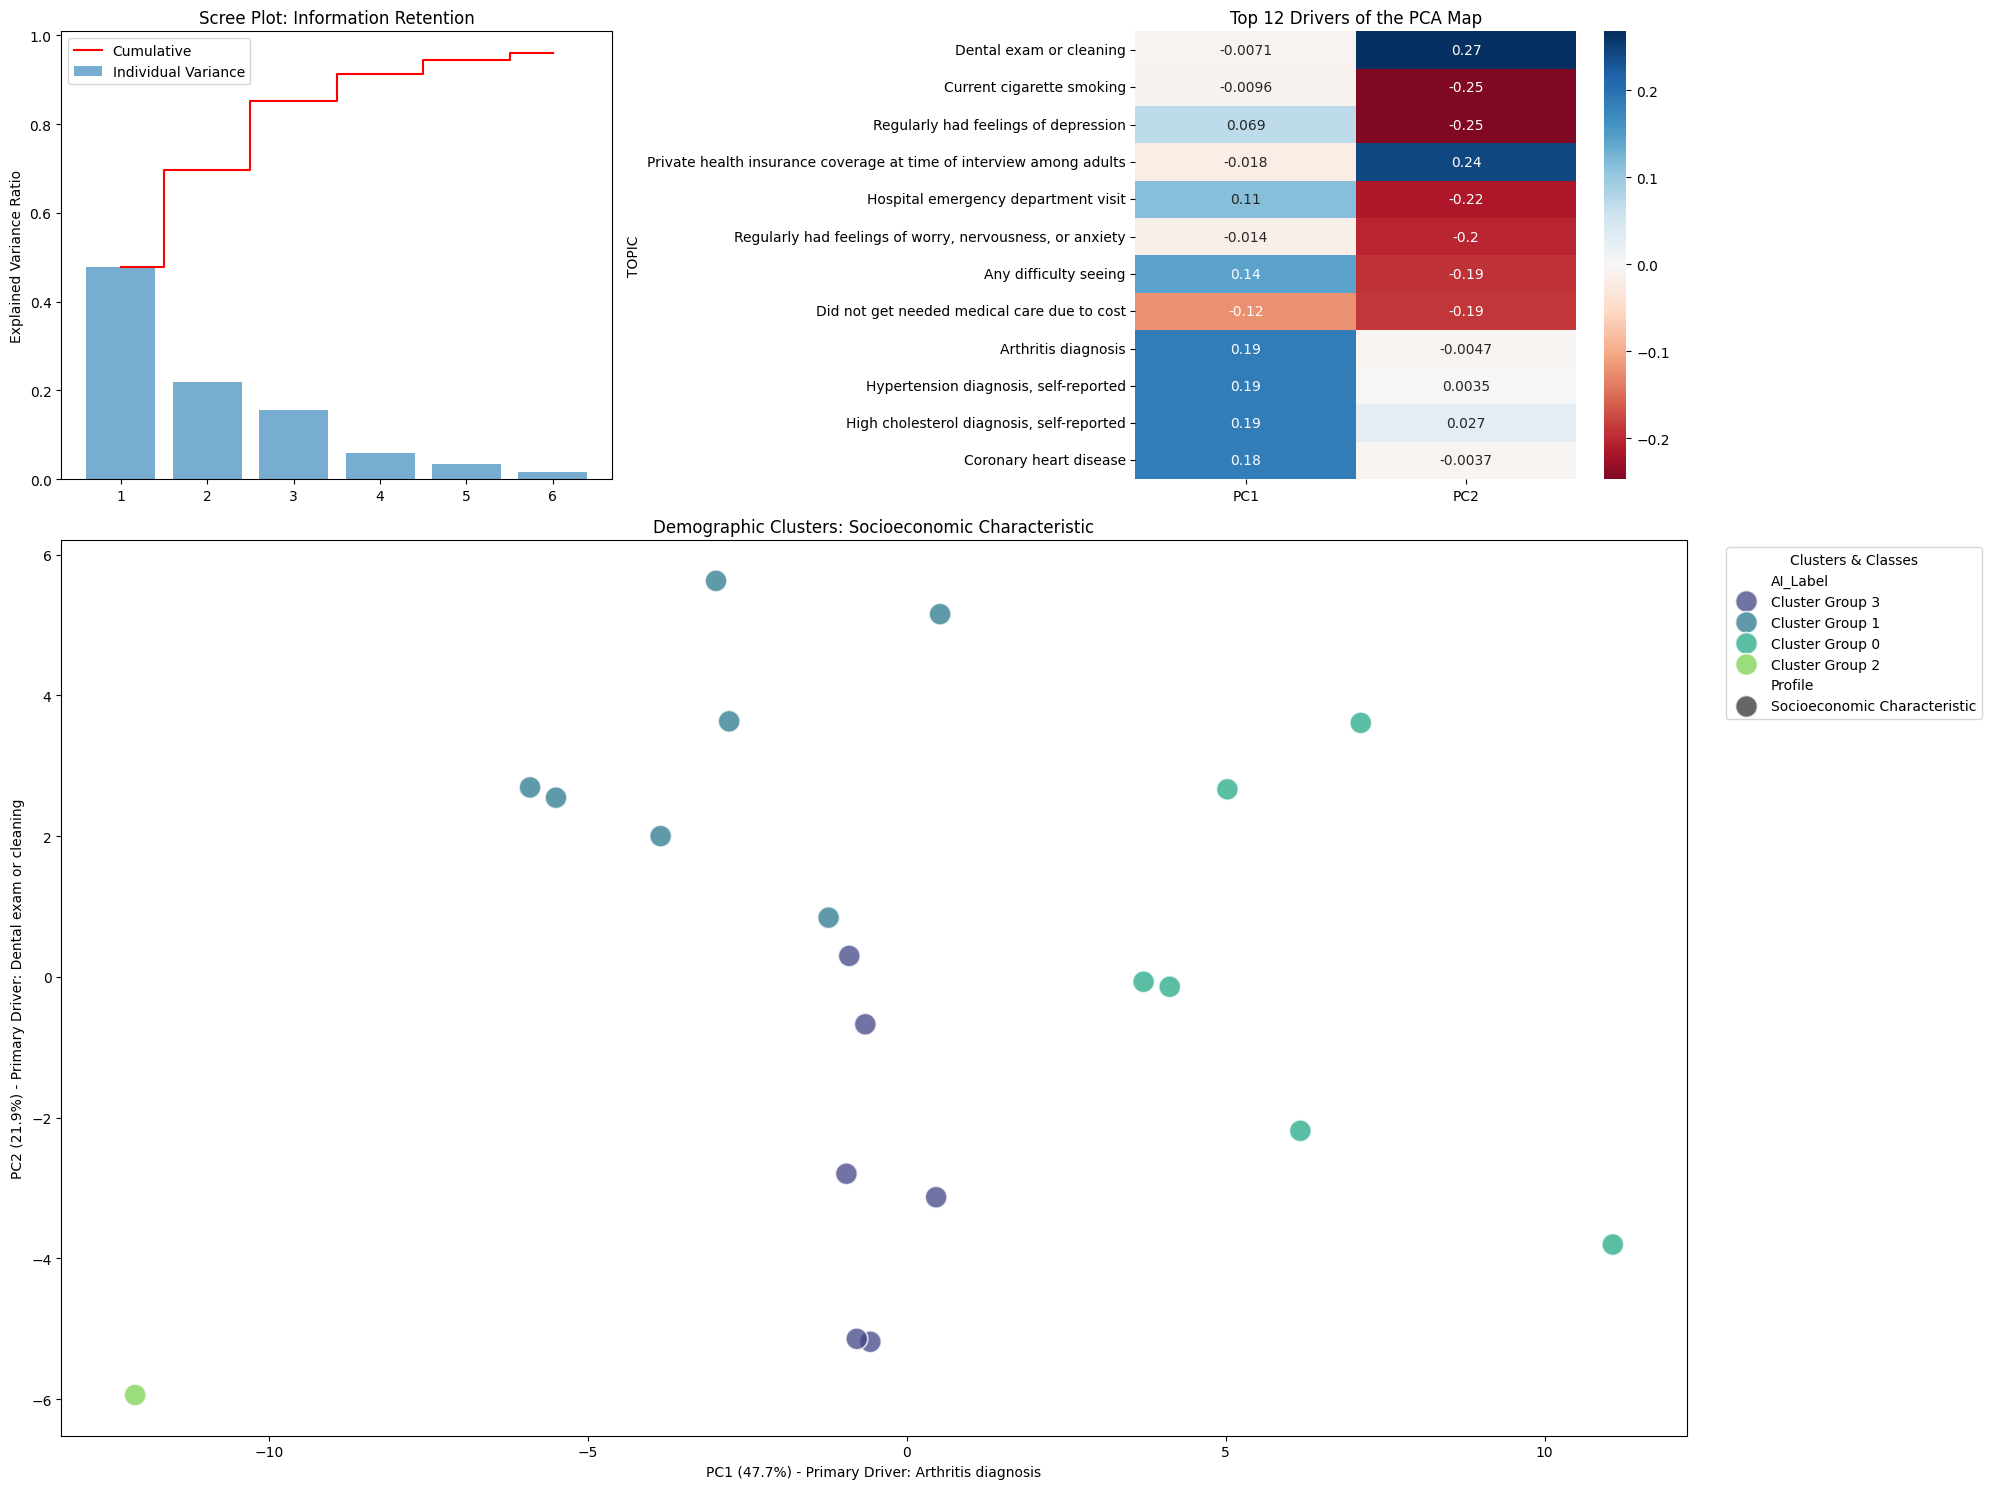


--- Cluster Group 0 (Cluster 0) ---
 • Socioeconomic Characteristic | Medicare Advantage
 • Socioeconomic Characteristic | Medicare and Medicaid
 • Socioeconomic Characteristic | Medicare only excluding Medicare Advantage
 • Socioeconomic Characteristic | Not employed (Not employed)
 • Socioeconomic Characteristic | Not employed - Has worked previously (Not employed)
 • Socioeconomic Characteristic | Other government coverage

--- Cluster Group 1 (Cluster 1) ---
 • Socioeconomic Characteristic | College degree or higher
 • Socioeconomic Characteristic | Employed (Employed)
 • Socioeconomic Characteristic | Employed - Full-time (Employed)
 • Socioeconomic Characteristic | Employed - Part-time (Employed)
 • Socioeconomic Characteristic | Not employed - Has never worked (Not employed)
 • Socioeconomic Characteristic | Private
 • Socioeconomic Characteristic | ≥200% FPL

--- Cluster Group 2 (Cluster 2) ---
 • Socioeconomic Characteristic | Uninsured

--- Cluster Group 3 (Cluster 3) ---
 •

In [ ]:
## @title PCA Analysis Settings { run: "auto" }
# @markdown Select which classification lens you want to view.
view_filter = "Socioeconomic Characteristic" # @param ["All", "Demographic Characteristic", "Socioeconomic Characteristic", "Geographic Characteristic"]
n_clusters = 4 # @param {type:"slider", min:2, max:10, step:1}

# ==========================================
# 1. DATA PREP & CLEANING
# ==========================================
df_2023 = df[(df['TIME_PERIOD'] == 2023) & (df['CLASSIFICATION'] != 'Total')].copy()
if view_filter != 'All':
    df_2023 = df_2023[df_2023['CLASSIFICATION'] == view_filter]

# Nesting Labels included in the Profile name
df_2023['Profile'] = df_2023.apply(
    lambda x: f"{x['CLASSIFICATION']} | {x['SUBGROUP']}" +
              (f" ({x['NESTING_LABEL']})" if pd.notnull(x['NESTING_LABEL']) else ""), axis=1
)

topic_df = df_2023.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE', aggfunc='mean')
topic_df_filled = topic_df.dropna(axis=1, thresh=len(topic_df) * 0.7).fillna(topic_df.mean())

# ==========================================
# 2. PCA & K-MEANS
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(topic_df_filled)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
topic_df_filled['Cluster'] = kmeans.fit_predict(X_pca[:, :2]).astype(str)

# ==========================================
# 3. HARD-CODED CLUSTER LABELS
# ==========================================
# You can manually rename these strings to whatever you like!
cluster_labels = {
    "0": "Cluster Group 0",
    "1": "Cluster Group 1",
    "2": "Cluster Group 2",
    "3": "Cluster Group 3",
    "4": "Cluster Group 4",
    "5": "Cluster Group 5",
    "6": "Cluster Group 6",
    "7": "Cluster Group 7",
    "8": "Cluster Group 8",
    "9": "Cluster Group 9"
}

# Map labels to the dataframe
topic_df_filled['AI_Label'] = topic_df_filled['Cluster'].map(cluster_labels)

# ==========================================
# 4. THE COMPLETE DASHBOARD
# ==========================================
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2])

# Plot A: Scree Plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, label='Individual Variance')
ax1.step(range(1, len(exp_var) + 1), np.cumsum(exp_var), where='mid', color='red', label='Cumulative')
ax1.set_title('Scree Plot: Information Retention')
ax1.set_ylabel('Explained Variance Ratio')
ax1.legend()

# Plot B: Loadings Heatmap
ax2 = fig.add_subplot(gs[0, 1])
# Drop non-numeric columns for loadings calculation
numeric_data = topic_df_filled.drop(columns=['Cluster', 'AI_Label'])
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(exp_var))], index=numeric_data.columns)
top_features = loadings[['PC1', 'PC2']].abs().max(axis=1).sort_values(ascending=False).head(12).index
sns.heatmap(loadings.loc[top_features, ['PC1', 'PC2']], annot=True, cmap='RdBu', center=0, ax=ax2)
ax2.set_title('Top 12 Drivers of the PCA Map')

# Plot C: The Cluster Map
ax3 = fig.add_subplot(gs[1, :])
mapping = df_2023.drop_duplicates('Profile').set_index('Profile')['CLASSIFICATION']
class_styles = topic_df_filled.index.map(mapping)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=topic_df_filled['AI_Label'],
                style=class_styles, s=250, palette='viridis', alpha=0.75, ax=ax3)

ax3.set_title(f'Demographic Clusters: {view_filter}')
ax3.set_xlabel(f'PC1 ({exp_var[0]:.1%}) - Primary Driver: {loadings["PC1"].idxmax()}')
ax3.set_ylabel(f'PC2 ({exp_var[1]:.1%}) - Primary Driver: {loadings["PC2"].idxmax()}')
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clusters & Classes")

plt.tight_layout()
plt.show()

# ==========================================
# 5. NEIGHBORHOOD REPORT
# ==========================================
for c in sorted(topic_df_filled['Cluster'].unique(), key=int):
    label = cluster_labels.get(c, f"Cluster {c}")
    print(f"\n--- {label} (Cluster {c}) ---")
    subgroups = topic_df_filled[topic_df_filled['Cluster'] == c].index.tolist()
    for name in subgroups[:10]:
        print(f" • {name}")
    if len(subgroups) > 10:
        print(f" ... and {len(subgroups) - 10} more.")

## Delayed Care Regression

Model R² Score: 0.69


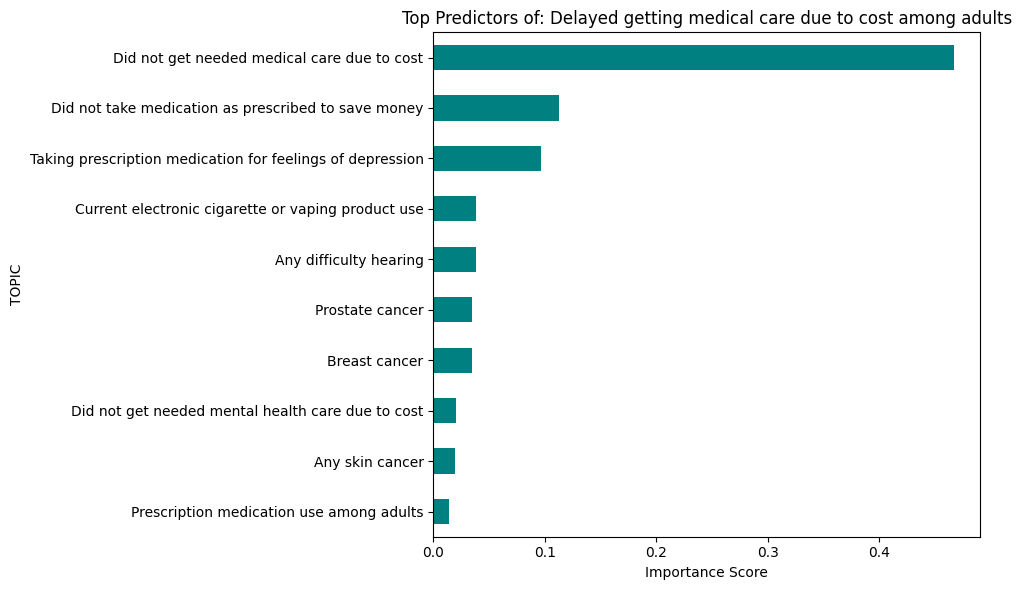

In [ ]:
# 1. Define Target and Features
# We'll predict 'Delayed getting medical care due to cost'
target_col = 'Delayed getting medical care due to cost among adults'
y = topic_df_filled[target_col]
X = topic_df_filled.drop(columns=[target_col])

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot Top 10 Features
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='teal')
plt.title(f'Feature Importance: {target_col}')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png')

print(f"Model R² Score: {r2_score(y_test, rf.predict(X_test)):.2f}")

## Forecast Modeling

In [1]:
from sklearn.preprocessing import PolynomialFeatures

# --- 1. DEFINE ACCESS TARGETS & DRIVERS ---
access_target = 'Delayed medical care due to cost among adults'
# These are the "Disease Load" features that often predict future access needs
burden_drivers = ['Diabetes among adults', 'Hypertension among adults', 'Asthma among adults']

# --- 2. FEATURE ENGINEERING FUNCTION ---
def engineer_access_features(pivot_df):
    temp_df = topic_df_filled.copy()

    # Create the Vulnerability Index: Avg Disease Burden * Insurance Gap
    if 'Uninsured at time of interview among adults' in temp_df.columns:
        temp_df['Chronic_Burden'] = temp_df[burden_drivers].mean(axis=1)
        temp_df['Access_Vulnerability'] = temp_df['Chronic_Burden'] * temp_df['Uninsured at time of interview among adults']

        # Polynomial: Is the cost-barrier accelerating at higher uninsured rates?
        temp_df['Uninsured_Sq'] = temp_df['Uninsured at time of interview among adults'] ** 2

    return temp_df

# --- 3. TRAIN ON MULTIPLE YEARS (2019-2024) ---
all_X = []
all_y = []

for yr in range(2019, 2024): # Train on pairs up to 2023->2024
    if yr in pivot_map and (yr+1) in pivot_map:
        X_yr = engineer_access_features(pivot_map[yr])
        y_yr = pivot_map[yr+1][access_target]

        common = X_yr.index.intersection(y_yr.index)
        all_X.append(X_yr.loc[common])
        all_y.append(y_yr.loc[common])

X_train_final = pd.concat(all_X)
y_train_final = pd.concat(all_y)

rf_access = RandomForestRegressor(n_estimators=100, random_state=42)
rf_access.fit(X_train_final, y_train_final)

# --- 4. RECURSIVE FORECAST TO 2026 ---
# Use 2024 data to get 2025, then 2025 to get 2026
current_features = engineer_access_features(pivot_map[2024])
pred_2025 = rf_access.predict(current_features)

# Simulate 2025 state to predict 2026
features_2025 = current_features.copy()
features_2025[access_target] = pred_2025 # Update target for the next hop
# Note: In a true multivariate model, you'd predict ALL columns for 2025 first

pred_2026 = rf_access.predict(features_2025)

# --- 5. RESULTS ---
results = pd.DataFrame({
    '2024_Actual': pivot_map[2024][access_target],
    '2026_Forecast': pred_2026,
    'Projected_Change': pred_2026 - pivot_map[2024][access_target]
}, index=pivot_map[2024].index)

print(results.sort_values('Projected_Change', ascending=False).head(10))

NameError: name 'pivot_map' is not defined